# DCGAN for Drinks

Prompt:
<b> I want to use this new dataset to train a DCGAN. </b>
- Remember it's a DCGAN. So I will need a deep generator and discriminator.
- Use best practices if I need to do any kind of cleaning on the images before sending them out. Everything from load to end should be done with tensorflow

OpenAI. (2025). Training a DCGAN [ChatGPT response]. OpenAI. Retrieved March 22, 2025, from https://chat.openai.com

In [34]:
import json
import os
import tensorflow as tf
import pandas as pd
from pathlib import Path
from scipy.linalg import sqrtm
from scipy.stats import entropy
import numpy as np
import shutil

In [2]:
PHOTOS_DIR = 'data/photos'
JSON_PATH = 'data/photos.json'

df_photos = pd.read_json('data/photos.json', lines=True)

In [3]:
df_photos['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [4]:
df_photos.groupby(['label']).size()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
dtype: int64

In [5]:
SOURCE_DIR = Path("data/photos")
DEST_DIR = Path("data/drinks")
#DEST_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
df_drinks = df_photos[df_photos['label'] == 'drink']

#for photo_id in df_drinks['photo_id']:
#    src = SOURCE_DIR / f"{photo_id}.jpg"
#    dst = DEST_DIR / f"{photo_id}.jpg"
#    if src.exists():
#        shutil.copy(src, dst)

# Save filtered JSON
df_drinks.to_json("data/drinks.json", orient="records", lines=True)

In [7]:
# Config
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 64  # You can adjust based on GPU memory
BUFFER_SIZE = 10000
DATA_DIR = Path("data/drinks")

# Preprocess each image
def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=CHANNELS)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = (image / 127.5) - 1  # Normalize to [-1, 1] for tanh
    return image

# Load dataset using tf.data
def load_dataset():
    files = tf.data.Dataset.list_files(str(DATA_DIR / "*.jpg"), shuffle=True)
    dataset = files.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Instantiate
train_dataset = load_dataset()


I0000 00:00:1742704403.315529    2139 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9511 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
def make_generator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4*4*512, use_bias=False, input_shape=(100,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Reshape((4, 4, 512)),

        tf.keras.layers.Conv2DTranspose(256, 5, strides=2, padding='same', use_bias=False),  # 8x8
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False),  # 16x16
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),   # 32x32
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(32, 5, strides=2, padding='same', use_bias=False),   # 64x64
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(3, 5, strides=2, padding='same', use_bias=False, activation='tanh')  # 128x128x3
    ])
    return model

generator = make_generator_model()

/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, 5, strides=2, padding='same', input_shape=[128, 128, 3]),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Conv2D(128, 5, strides=2, padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Conv2D(256, 5, strides=2, padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])
    return model

discriminator = make_discriminator_model()

/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    # Instead of 1.0 for real
    real_labels = tf.ones_like(real_output) * 0.9
    real_loss = cross_entropy(real_labels, real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [11]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.4)
discriminator_optimizer = tf.keras.optimizers.Adam(5e-5, beta_1=0.4)

In [12]:
import time
import os
from matplotlib import pyplot as plt

EPOCHS = 500
NOISE_DIM = 100
NUM_EXAMPLES_TO_GENERATE = 16
CHECKPOINT_DIR = 'models/training_checkpoints'
OUTPUT_IMAGE_DIR = 'data/generated_images'

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)
manager = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)

In [13]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [14]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1) / 2.0  # Rescale to [0, 1]

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i])
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_IMAGE_DIR}/epoch_{epoch:04d}.png')
    plt.close()

In [15]:
from tqdm import tqdm

In [16]:
def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        start = time.time()
        gen_loss_avg = tf.keras.metrics.Mean()
        disc_loss_avg = tf.keras.metrics.Mean()

        print(f"\nEpoch {epoch}/{epochs}")
        for image_batch in tqdm(dataset, desc=f"Training Epoch {epoch}"):
            gen_loss, disc_loss = train_step(image_batch)
            gen_loss_avg.update_state(gen_loss)
            disc_loss_avg.update_state(disc_loss)

        # Generate sample images
        generate_and_save_images(generator, epoch, seed)

        # Save checkpoints
        if epoch % 10 == 0:
            manager.save()

        print(f"Gen Loss: {gen_loss_avg.result():.4f}, Disc Loss: {disc_loss_avg.result():.4f}, Time: {time.time() - start:.2f}s")

In [17]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DISABLE_LAYOUT'] = '1'

tf.get_logger().setLevel('ERROR')

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='PIL')

In [18]:
train(train_dataset, EPOCHS)


Epoch 1/500


Training Epoch 1:   0%|                                                                         | 0/245 [00:00<?, ?it/s]2025-03-23 00:33:29.850536: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:30.578754: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:34.004818: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:34.851370: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:34.921117: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:36.508775: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:37.378009: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
E0000 00:00:1742704419.198777    2139 meta_optimizer.cc:966] layout 

Gen Loss: 1.1044, Disc Loss: 1.1702, Time: 27.45s

Epoch 2/500


Training Epoch 2:   0%|                                                                         | 0/245 [00:00<?, ?it/s]2025-03-23 00:33:57.061028: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:57.754670: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:57.880947: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:58.747090: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:33:59.190868: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 00:34:00.323071: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 2: 100%|███████████████████████████████████████████████████████████████| 245/245 [00:21<00:00, 11.33it/s]


Gen Loss: 1.1366, Disc Loss: 1.1845, Time: 21.91s

Epoch 3/500


...

Gen Loss: 2.2427, Disc Loss: 0.7638, Time: 29.90s

Epoch 499/500


Training Epoch 499:   0%|                                                                       | 0/245 [00:00<?, ?it/s]2025-03-23 05:18:10.666072: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:12.414920: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:13.631888: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:14.497251: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:14.824591: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 499: 100%|█████████████████████████████████████████████████████████████| 245/245 [00:29<00:00,  8.22it/s]


Gen Loss: 2.2117, Disc Loss: 0.7770, Time: 30.05s

Epoch 500/500


Training Epoch 500:   0%|                                                                       | 0/245 [00:00<?, ?it/s]2025-03-23 05:18:41.897137: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:43.263110: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:43.557036: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:44.728274: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:44.965752: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 05:18:45.098069: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 500: 100%|█████████████████████████████████████████████████████████████| 245/245 [00:29<00:00,  8.28it/s]


Gen Loss: 2.2448, Disc Loss: 0.7587, Time: 30.39s


<b> I used another prompt for the next step:
- now I need to Evaluate the models using Inception Score and Frechet Inception Distance using a pretrained model
- and plot 5 generated images in jupyter lab

In [64]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [88]:
mobilenet = tf.keras.applications.MobileNetV2(
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [87]:
def preprocess_for_mobilenet(images):
    images = tf.image.resize(images, [224, 224])
    return preprocess_input(images * 255.0)  # Scale from [0,1] → [0,255]


In [89]:
def get_activations(images, batch_size=16):
    images = preprocess_for_mobilenet(images)
    activations = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i+batch_size]
        with tf.device('/CPU:0'):  # or remove this if you want to try GPU again
            feats = mobilenet(batch, training=False)
        activations.append(feats)
    return tf.concat(activations, axis=0)


In [103]:
def calculate_fid(real_act, fake_act):
    # Flatten from [N, H, W, C] to [N, features]
    real_act = tf.reshape(real_act, [real_act.shape[0], -1]).numpy()
    fake_act = tf.reshape(fake_act, [fake_act.shape[0], -1]).numpy()

    mu1 = np.mean(real_act, axis=0)
    mu2 = np.mean(fake_act, axis=0)
    sigma1 = np.cov(real_act, rowvar=False)
    sigma2 = np.cov(fake_act, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)


In [91]:
from scipy.stats import entropy

def calculate_inception_score(features, splits=10):
    preds = tf.nn.softmax(features).numpy()
    split_scores = []
    N = preds.shape[0]
    for k in range(splits):
        part = preds[k * (N // splits): (k + 1) * (N // splits), :]
        py = np.mean(part, axis=0)
        scores = [entropy(p, py) for p in part]
        split_scores.append(np.mean(scores))
    return np.exp(np.mean(split_scores))

In [92]:
# Generate fake images from generator
def generate_fake_images(generator, num_images=1000, batch_size=100, noise_dim=100):
    fake_images = []
    for _ in range(num_images // batch_size):
        noise = tf.random.normal([batch_size, noise_dim])
        generated = generator(noise, training=False)
        generated = (generated + 1.0) / 2.0  
        fake_images.append(generated)
    return tf.concat(fake_images, axis=0)

# Get real images from training dataset
def get_real_images(dataset, num_images=1000):
    real_images = []
    for batch in dataset:
        batch = (batch + 1.0) / 2.0 
        real_images.append(batch)
        if sum(x.shape[0] for x in real_images) >= num_images:
            break
    return tf.concat(real_images, axis=0)[:num_images]


In [93]:
fake_imgs = generate_fake_images(generator, num_images=1000)
real_imgs = get_real_images(train_dataset, num_images=1000)

act_fake = get_activations(fake_imgs)
act_real = get_activations(real_imgs)

fid_score = calculate_fid(act_real.numpy(), act_fake.numpy())
is_score = calculate_inception_score(fake_imgs)

print(f"Inception Score: {is_score:.4f}")
print(f"FID Score: {fid_score:.4f}")

2025-03-23 11:44:31.455646: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:31.762526: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:32.801520: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:32.941208: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:33.000079: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:33.478244: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:34.014675: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:34.245420: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-23 11:44:35.692016: W tensorflow/core/lib/png/png_io.cc:89] PNG 

Inception Score: 1.0025
FID Score: 653.5449


In [94]:
import matplotlib.pyplot as plt

def plot_generated_images(generator, num_images=5):
    noise = tf.random.normal([num_images, 100])
    generated_images = generator(noise, training=False)
    generated_images = (generated_images + 1.0) / 2.0  # Rescale to [0, 1]

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
    plt.show()


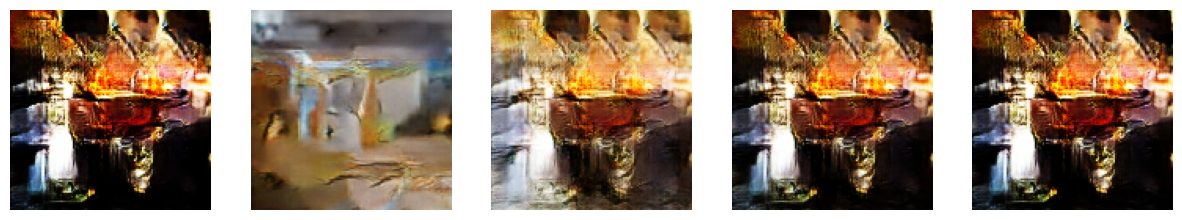

In [95]:
plot_generated_images(generator)